# TwiBot-20 transfer-in: merged-strategy NM models -> bot detection

Evaluate the 9 checkpoints from the merged-vs-single NM study (ukr/covid and
covid/midterm experiments) on the held-out **TwiBot-20** retweet graph. Two eval
tasks: **neighbor matching** (30-way, 3-shot) and **bot-vs-human classification**
(few-shot). Metrics are zero-adaptation test scores downloaded from the Tucker
eval logs into `twibot20_eval_metrics.csv`.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

DATA = Path("twibot20_eval_metrics.csv")
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

df = pd.read_csv(DATA)

LABEL = {
    "nm_matrix_ukr": "ukr\n(single)",
    "nm_matrix_covid": "covid\n(single)",
    "nm_matrix_merged": "ukr+cov\n(prop)",
    "nm_xsrc_within_source": "ukr+cov\n(within)",
    "nm_cm_covid": "covid\n(single)",
    "nm_cm_midterm": "midterm\n(single)",
    "nm_cm_merged": "cov+mid\n(prop)",
    "nm_cm_within": "cov+mid\n(within)",
    "nm_cm_within_balanced": "cov+mid\n(within-bal)",
}
STRAT_COLOR = {
    "single": "#8a8f98",
    "merged_proportional": "#2f6f9f",
    "merged_within": "#5a9f72",
    "merged_within_balanced": "#b45f4d",
}
ORDER = {
    "ukr_covid": ["nm_matrix_ukr","nm_matrix_covid","nm_matrix_merged","nm_xsrc_within_source"],
    "covid_midterm": ["nm_cm_covid","nm_cm_midterm","nm_cm_merged","nm_cm_within","nm_cm_within_balanced"],
}
df["label"] = df["model"].map(LABEL)
df.head()

,model,experiment,strategy,source,task,accuracy,f1,roc_auc,label
0,nm_cm_merged,covid_midterm,merged_proportional,covid+midterm,classification,0.550167,0.558843,0.569516,cov+mid\n(prop)
1,nm_cm_within,covid_midterm,merged_within,covid+midterm,classification,0.555167,0.563818,0.584024,cov+mid\n(within)
2,nm_cm_within_balanced,covid_midterm,merged_within_balanced,covid+midterm,classification,0.543750,0.546734,0.560020,cov+mid\n(within-bal)
3,nm_cm_covid,covid_midterm,single,covid,classification,0.550583,0.536006,0.575411,covid\n(single)
4,nm_cm_midterm,covid_midterm,single,midterm,classification,0.536000,0.533199,0.543310,midterm\n(single)


In [2]:
# Wide tables per task
cls = df[df.task.eq("classification")].set_index("model")[["source","strategy","accuracy","f1","roc_auc"]]
nm  = df[df.task.eq("nm")].set_index("model")[["source","strategy","accuracy","f1","roc_auc"]]
print("Classification (bot vs human), chance = 0.50"); display(cls.round(4))
print("Neighbor matching (30-way 3-shot), chance acc = 0.033"); display(nm.round(4))

Classification (bot vs human), chance = 0.50


,source,strategy,accuracy,f1,roc_auc
model,,,,,
nm_cm_merged,covid+midterm,merged_proportional,0.5502,0.5588,0.5695
nm_cm_within,covid+midterm,merged_within,0.5552,0.5638,0.5840
nm_cm_within_balanced,covid+midterm,merged_within_balanced,0.5438,0.5467,0.5600
nm_cm_covid,covid,single,0.5506,0.5360,0.5754
nm_cm_midterm,midterm,single,0.5360,0.5332,0.5433
nm_matrix_merged,ukr+covid,merged_proportional,0.5407,0.5362,0.5590
nm_xsrc_within_source,ukr+covid,merged_within,0.5465,0.5662,0.5676
nm_matrix_covid,covid,single,0.5591,0.5620,0.5859
nm_matrix_ukr,ukr,single,0.5691,0.5710,0.5941


Neighbor matching (30-way 3-shot), chance acc = 0.033


,source,strategy,accuracy,f1,roc_auc
model,,,,,
nm_cm_merged,covid+midterm,merged_proportional,0.4139,0.4139,0.9258
nm_cm_within,covid+midterm,merged_within,0.4130,0.4130,0.9270
nm_cm_within_balanced,covid+midterm,merged_within_balanced,0.3930,0.3930,0.9206
nm_cm_covid,covid,single,0.4100,0.4100,0.9275
nm_cm_midterm,midterm,single,0.2634,0.2633,0.8651
nm_matrix_merged,ukr+covid,merged_proportional,0.4044,0.4045,0.9232
nm_xsrc_within_source,ukr+covid,merged_within,0.4129,0.4130,0.9282
nm_matrix_covid,covid,single,0.4062,0.4062,0.9240
nm_matrix_ukr,ukr,single,0.3987,0.3987,0.9235


Chance levels: classification is 2-way so accuracy/ROC-AUC chance = **0.50**;
NM is 30-way so accuracy chance = **0.033**. Bars are colored by merge strategy
(grey = single-source, blue = merged-proportional, green = merged-within-source,
red = within-balanced).

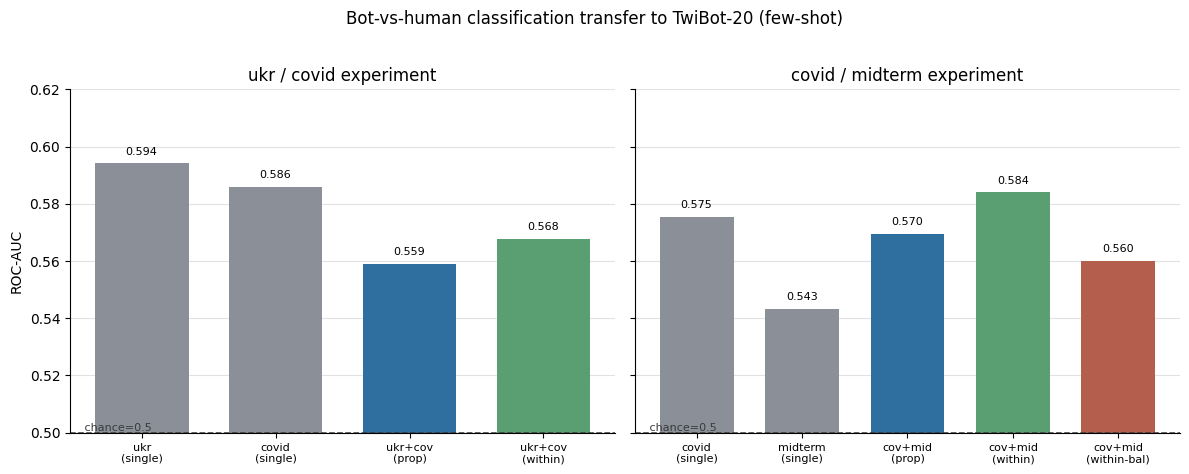

In [3]:
def style_axis(ax):
    ax.spines[["top","right"]].set_visible(False)
    ax.grid(axis="y", color="#d7d7d7", linewidth=0.8, alpha=0.7)
    ax.set_axisbelow(True)

def annotate(ax, bars, fmt="{:.3f}"):
    ymin, ymax = ax.get_ylim(); pad = (ymax - ymin) * 0.02
    for b in bars:
        v = b.get_height()
        ax.text(b.get_x()+b.get_width()/2, v+pad, fmt.format(v),
                ha="center", va="bottom", fontsize=8)

def panel(ax, exp, task, metric, title, chance=None, ylim=None):
    order = ORDER[exp]
    sub = df[df.experiment.eq(exp) & df.task.eq(task)].set_index("model").reindex(order)
    bars = ax.bar(range(len(order)), sub[metric].values,
                  color=[STRAT_COLOR[s] for s in sub["strategy"]], width=0.7)
    ax.set_xticks(range(len(order))); ax.set_xticklabels([LABEL[m] for m in order], fontsize=8)
    if ylim: ax.set_ylim(*ylim)
    if chance is not None:
        ax.axhline(chance, color="#3a3a3a", ls="--", lw=1.1)
        ax.text(0.02, chance, f" chance={chance}", transform=ax.get_yaxis_transform(),
                va="bottom", ha="left", fontsize=8, color="#3a3a3a")
    ax.set_title(title); style_axis(ax); annotate(ax, bars)
    return sub

# --- Bot-vs-human classification (ROC-AUC) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
panel(axes[0], "ukr_covid", "classification", "roc_auc", "ukr / covid experiment", chance=0.5, ylim=(0.5, 0.62))
panel(axes[1], "covid_midterm", "classification", "roc_auc", "covid / midterm experiment", chance=0.5, ylim=(0.5, 0.62))
axes[0].set_ylabel("ROC-AUC")
fig.suptitle("Bot-vs-human classification transfer to TwiBot-20 (few-shot)", y=1.02)
fig.tight_layout(); fig.savefig(FIG_DIR/"classification_roc_auc.png", dpi=200, bbox_inches="tight")

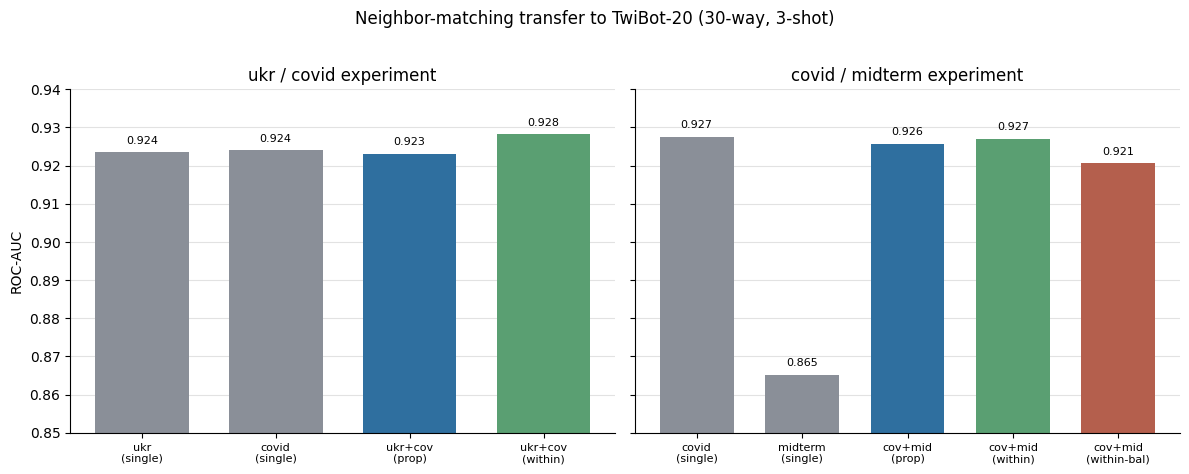

In [4]:
# --- Neighbor matching (ROC-AUC) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
panel(axes[0], "ukr_covid", "nm", "roc_auc", "ukr / covid experiment", ylim=(0.85, 0.94))
panel(axes[1], "covid_midterm", "nm", "roc_auc", "covid / midterm experiment", ylim=(0.85, 0.94))
axes[0].set_ylabel("ROC-AUC")
fig.suptitle("Neighbor-matching transfer to TwiBot-20 (30-way, 3-shot)", y=1.02)
fig.tight_layout(); fig.savefig(FIG_DIR/"nm_roc_auc.png", dpi=200, bbox_inches="tight")

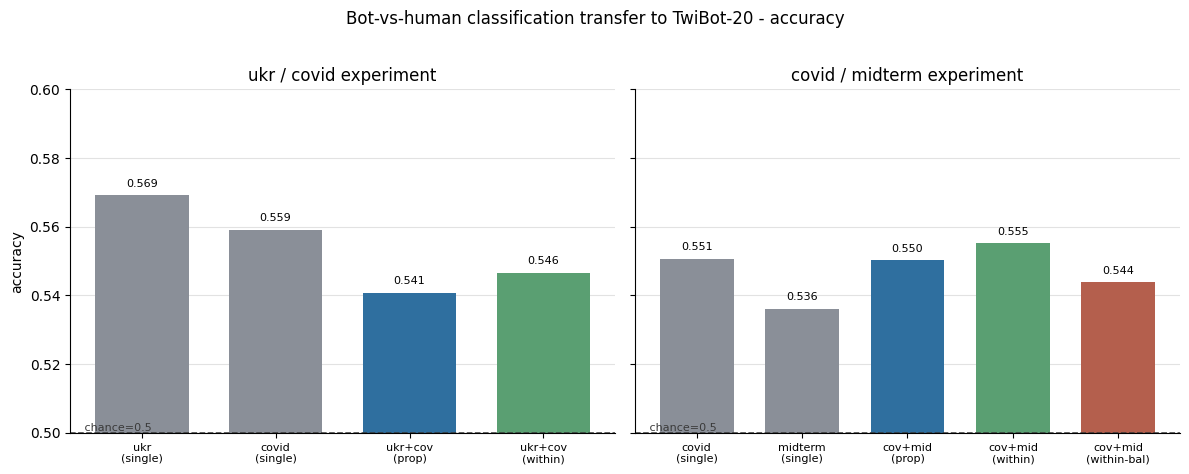

In [5]:
# --- Classification accuracy (same layout) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True)
panel(axes[0], "ukr_covid", "classification", "accuracy", "ukr / covid experiment", chance=0.5, ylim=(0.5, 0.60))
panel(axes[1], "covid_midterm", "classification", "accuracy", "covid / midterm experiment", chance=0.5, ylim=(0.5, 0.60))
axes[0].set_ylabel("accuracy")
fig.suptitle("Bot-vs-human classification transfer to TwiBot-20 - accuracy", y=1.02)
fig.tight_layout(); fig.savefig(FIG_DIR/"classification_accuracy.png", dpi=200, bbox_inches="tight")

In [6]:
# Rankings
print("=== Classification (bot detection) ranked by ROC-AUC ===")
display(df[df.task.eq("classification")].sort_values("roc_auc", ascending=False)
        [["source","strategy","experiment","accuracy","f1","roc_auc"]].round(4).reset_index(drop=True))
print("=== NM ranked by ROC-AUC ===")
display(df[df.task.eq("nm")].sort_values("roc_auc", ascending=False)
        [["source","strategy","experiment","accuracy","roc_auc"]].round(4).reset_index(drop=True))

=== Classification (bot detection) ranked by ROC-AUC ===


,source,strategy,experiment,accuracy,f1,roc_auc
0,ukr,single,ukr_covid,0.5691,0.5710,0.5941
1,covid,single,ukr_covid,0.5591,0.5620,0.5859
2,covid+midterm,merged_within,covid_midterm,0.5552,0.5638,0.5840
3,covid,single,covid_midterm,0.5506,0.5360,0.5754
4,covid+midterm,merged_proportional,covid_midterm,0.5502,0.5588,0.5695
5,ukr+covid,merged_within,ukr_covid,0.5465,0.5662,0.5676
6,covid+midterm,merged_within_balanced,covid_midterm,0.5438,0.5467,0.5600
7,ukr+covid,merged_proportional,ukr_covid,0.5407,0.5362,0.5590
8,midterm,single,covid_midterm,0.5360,0.5332,0.5433


=== NM ranked by ROC-AUC ===


,source,strategy,experiment,accuracy,roc_auc
0,ukr+covid,merged_within,ukr_covid,0.4129,0.9282
1,covid,single,covid_midterm,0.4100,0.9275
2,covid+midterm,merged_within,covid_midterm,0.4130,0.9270
3,covid+midterm,merged_proportional,covid_midterm,0.4139,0.9258
4,covid,single,ukr_covid,0.4062,0.9240
5,ukr,single,ukr_covid,0.3987,0.9235
6,ukr+covid,merged_proportional,ukr_covid,0.4044,0.9232
7,covid+midterm,merged_within_balanced,covid_midterm,0.3930,0.9206
8,midterm,single,covid_midterm,0.2634,0.8651


## Takeaways

- **NM representations transfer structurally** (ROC-AUC ~0.92-0.93 everywhere)
  except `midterm`-only, which is the weakest source on both tasks
  (NM AUC 0.865, acc 0.26).
- **Bot detection transfer is weak** (ROC-AUC ~0.54-0.59) - expected, since these
  models were pretrained with unsupervised neighbor matching and never saw bot
  labels.
- **No merge strategy wins bot detection**: single-source `ukr` / `covid` are
  marginally best; the merged / within-source variants cluster just below. The
  merged-vs-single ordering from the original study does not carry over to this
  held-out target.